# Chasing the Lights - Analyse geomagnetischer Stürme

## 1. Setup und Bibliotheken

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Design-Einstellungen für wissenschaftliche Grafiken
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# Warnungen unterdrücken (optional, für saubereren Output)
import warnings
warnings.filterwarnings('ignore')

## 2. Datenimport

In [7]:
# Relativer Pfad zur Datendatei
file_path = 'omni_data.txt'

# Prüfen, ob die Datei existiert
if os.path.exists(file_path):
    print(f"Datei gefunden: {file_path}")
    
    # Spaltennamen definieren (basierend auf OMNIWeb Header)
    col_names = ['Year', 'DOY', 'Hour', 'By', 'Bz', 'Density', 'Speed', 'Kp_10']
    
    # Einlesen der Textdatei (Trennzeichen: Whitespace)
    df = pd.read_csv(file_path, delim_whitespace=True, names=col_names)
    print("Rohdaten erfolgreich geladen.")
else:
    print(f"FEHLER: Datei '{file_path}' nicht gefunden. Bitte Pfad prüfen.")

Datei gefunden: omni_data.txt
Rohdaten erfolgreich geladen.


## 3. Datenbereinigung (Preprocessing)

In [8]:
# Kopie erstellen, um Warnungen zu vermeiden
df_clean = df.copy()

# 1. Zeitstempel generieren
# Kombination aus Jahr, Tag des Jahres (DOY) und Stunde zu einem Datetime-Objekt
df_clean['Datetime'] = pd.to_datetime(df_clean['Year'] * 1000 + df_clean['DOY'], format='%Y%j') + pd.to_timedelta(df_clean['Hour'], unit='h')
df_clean = df_clean.set_index('Datetime')

# 2. Fehlwerte behandeln
# OMNIWeb nutzt 999.9 etc. als Platzhalter für fehlende Messungen
error_values = [999.9, 9999.99, 999.99, 9999, 99.9]
df_clean = df_clean.replace(error_values, np.nan)

# 3. Zielvariable skalieren
# Kp-Index ist als Faktor 10 gespeichert (33 -> 3.3)
df_clean['Kp'] = df_clean['Kp_10'] / 10.0

# 4. Finaler Datensatz
# Nur relevante Spalten behalten und Zeilen mit NaNs entfernen
cols_to_keep = ['Bz', 'Speed', 'Density', 'Kp']
df_clean = df_clean[cols_to_keep].dropna()

print(f"Daten bereinigt. Verbleibende Datenpunkte: {len(df_clean)}")
print(df_clean.describe())  

Daten bereinigt. Verbleibende Datenpunkte: 182259
                  Bz          Speed        Density             Kp
count  182259.000000  182259.000000  182259.000000  182259.000000
mean       -0.019455     421.111654       6.070953       1.640859
std         2.682689      97.450710       4.869279       1.277383
min       -46.500000     233.000000       0.100000       0.000000
25%        -1.300000     348.000000       3.000000       0.700000
50%         0.000000     398.000000       4.700000       1.300000
75%         1.200000     475.000000       7.500000       2.300000
max        37.500000    1154.000000     137.200000       9.000000


## 4. Explorative Datenanalyse: Korrelationen

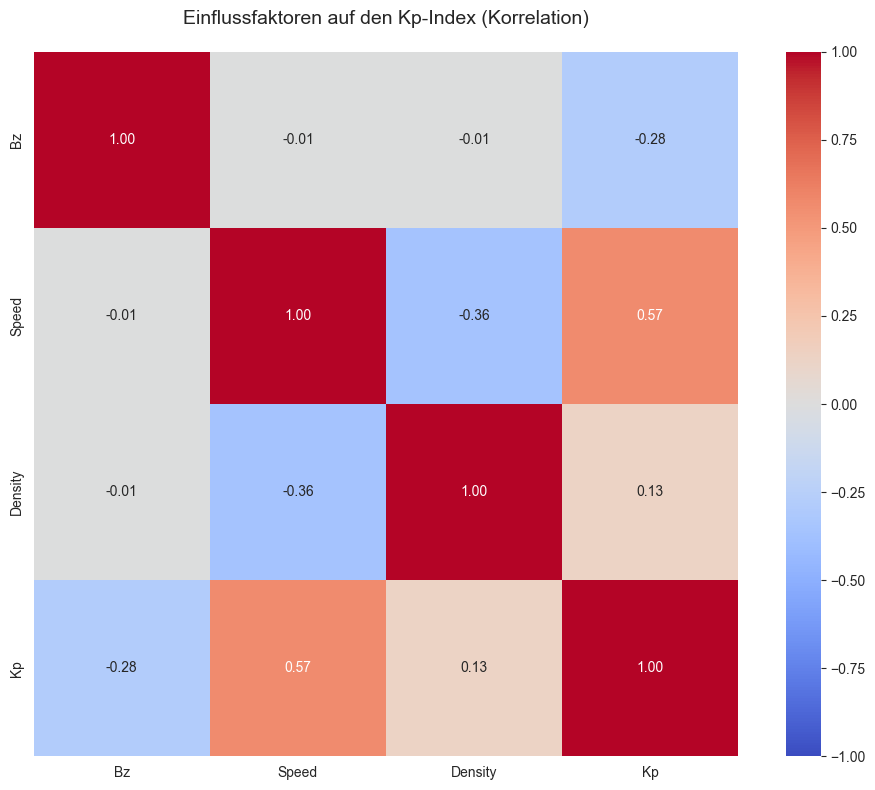

In [11]:
    # Berechnung der Korrelationsmatrix nach Pearson
corr_matrix = df_clean.corr()

# Visualisierung als Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title('Einflussfaktoren auf den Kp-Index (Korrelation)', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('grafik_1_heatmap.png', dpi=300) # Hier passiert die Magie (hohe Auflösung)
plt.show()

## 5. Visualisierung der Hypothesen

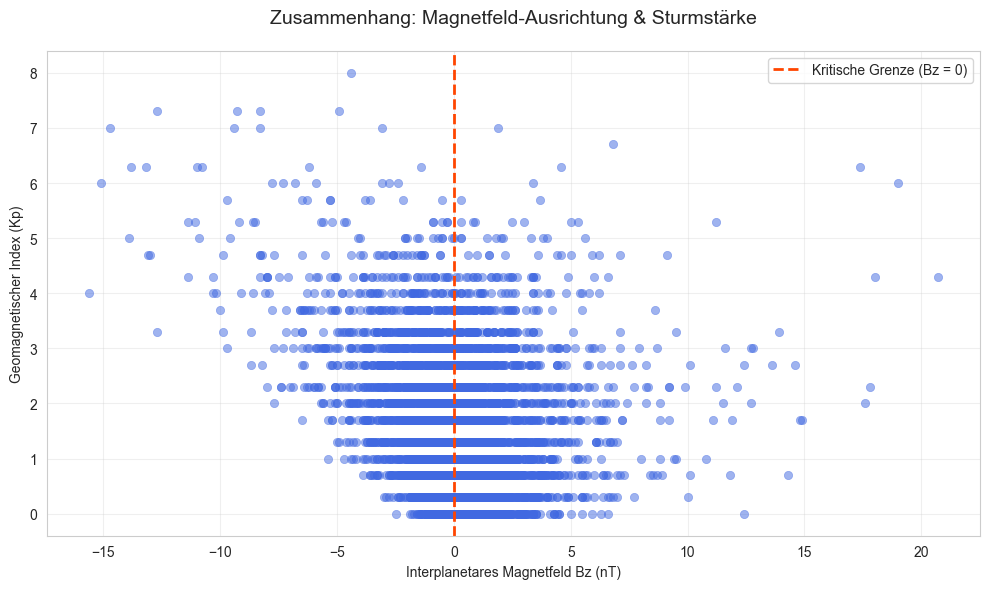

In [12]:
#2 Scatterplot (Punktewolke)
df_sample = df_clean.sample(n=5000, random_state=42)
plt.figure(figsize=(10, 6))
# alpha=0.5 macht die Punkte leicht durchsichtig -> sieht edler aus
sns.scatterplot(x='Bz', y='Kp', data=df_sample, alpha=0.5, color='#4169E1', edgecolor=None)
plt.axvline(0, color='#FF4500', linestyle='--', linewidth=2, label='Kritische Grenze (Bz = 0)')
plt.title('Zusammenhang: Magnetfeld-Ausrichtung & Sturmstärke', fontsize=14, pad=20)
plt.xlabel('Interplanetares Magnetfeld Bz (nT)')
plt.ylabel('Geomagnetischer Index (Kp)')
plt.legend(loc='upper right', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafik_2_scatterplot.png', dpi=300)
plt.show()

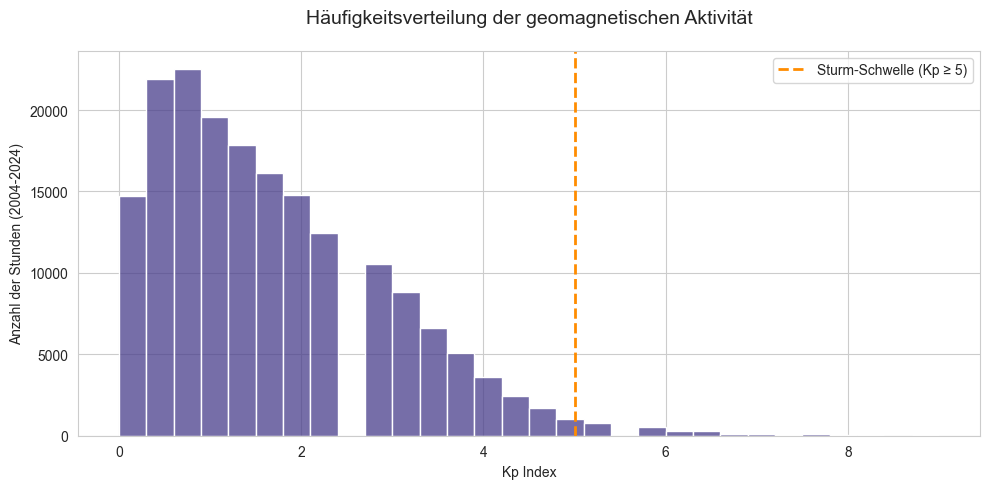

In [13]:
# 3. Histogramm (Verteilung)
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Kp'], bins=30, kde=False, color='#483D8B', edgecolor='white')
plt.axvline(5, color='#FF8C00', linestyle='--', linewidth=2, label='Sturm-Schwelle (Kp ≥ 5)')
plt.title('Häufigkeitsverteilung der geomagnetischen Aktivität', fontsize=14, pad=20)
plt.xlabel('Kp Index')
plt.ylabel('Anzahl der Stunden (2004-2024)')
plt.legend()
plt.tight_layout()
plt.savefig('grafik_3_histogramm.png', dpi=300)
plt.show()